# Pratiksha Somnath Avhad
## Data Analytics – Level 1
### Task 3: Cleaning Data

**Objective:** 
    To identify and handle missing values, duplicate records, inconsistent formatting, incorrect data types, and outliers
    in a dataset using Python and Pandas.

## 1. Introduction

Data cleaning is an important step in data analysis. 
It helps improve data quality by identifying and handling missing values, duplicate records, inconsistent formats,
incorrect data types, and outliers.

In this task, we will use the Titanic dataset and perform data cleaning using Python and Pandas. 
We will compare the dataset before and after cleaning and save the cleaned data as a new CSV file.

### Objectives
- Identify missing values and duplicate records.
- Handle missing data using suitable methods.
- Check inconsistent values and data types.
- Detect and handle outliers.
- Compare data quality before and after cleaning.
- Export the cleaned dataset to a CSV file.

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("Titanic.csv")

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

df.head()

Dataset loaded successfully!
Shape of dataset: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (891, 12)

Column Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## 2. Understanding the Dataset

The Titanic dataset contains information about 891 passengers and 12 columns.
It includes passenger details such as passenger ID, survival status, ticket class, name, age, gender, family members,
ticket number, fare, cabin, and port of embarkation.

This dataset will be used to identify and handle data quality issues such as missing values, duplicate records, 
incorrect data types, and outliers.

In [4]:
# Check missing values in each column
print("Missing Values:")
print(df.isnull().sum())

# Check total missing values
print("\nTotal Missing Values:", df.isnull().sum().sum())

# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Total Missing Values: 866

Duplicate Rows: 0


In [5]:
# Check data types
print("Data Types:")
print(df.dtypes)

# Check numerical columns summary
print("\nNumerical Summary:")
df.describe()

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Numerical Summary:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Observation
The dataset contains 12 columns with appropriate data types. The Age column has 177 missing values. 
Age ranges from 0.42 to 80 years, while Fare ranges from 0 to 512.33.

In [6]:
# Check unique values in categorical columns
print("Sex values:")
print(df["Sex"].unique())

print("\nEmbarked values:")
print(df["Embarked"].unique())

print("\nPclass values:")
print(df["Pclass"].unique())

Sex values:
['male' 'female']

Embarked values:
['S' 'C' 'Q' nan]

Pclass values:
[3 1 2]


### Observation
The Sex column contains two values: male and female. The Embarked column contains S, C, Q, and missing values. 
    The Pclass column contains values 1, 2, and 3. No inconsistent text values were found in these columns.

In [7]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


### Observation
No duplicate rows were found in the dataset. Therefore, no duplicate records need to be removed.

In [8]:
# Create a copy of the original dataset
df_clean = df.copy()

# Fill missing Age values with median
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())

# Fill missing Embarked values with mode
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])

# Drop Cabin column due to many missing values
df_clean = df_clean.drop(columns=["Cabin"])

print("Missing values after handling:")
print(df_clean.isnull().sum())

print("\nDataset shape after handling missing values:", df_clean.shape)

Missing values after handling:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Dataset shape after handling missing values: (891, 11)


### Observation
Missing values were handled successfully. Age values were filled using the median, Embarked values using the mode, 
and the Cabin column was removed because it contained many missing values. The cleaned dataset contains 891 rows and 11 columns
with no missing values.

In [9]:
# Check duplicate rows in the cleaned dataset
duplicate_count = df_clean.duplicated().sum()

print("Duplicate rows before removal:", duplicate_count)

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

print("Duplicate rows after removal:", df_clean.duplicated().sum())
print("Dataset shape after removing duplicates:", df_clean.shape)

Duplicate rows before removal: 0
Duplicate rows after removal: 0
Dataset shape after removing duplicates: (891, 11)


### Observation
No duplicate rows were found in the cleaned dataset. Therefore, no records were removed, and the dataset remains at 891 rows 
and 11 columns.

In [10]:
# Check current data types
print("Data types before conversion:")
print(df_clean.dtypes)

# Convert PassengerId to string because it is an identifier
df_clean["PassengerId"] = df_clean["PassengerId"].astype(str)

print("\nData types after conversion:")
print(df_clean.dtypes)

Data types before conversion:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object

Data types after conversion:
PassengerId     object
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object


### Observation
The PassengerId column was converted from integer to object because it is an identifier, not a value used for calculations.
The remaining columns retain their suitable data types.

In [11]:
# Select numerical columns for outlier detection
numeric_cols = ["Age", "Fare", "SibSp", "Parch"]

# Detect outliers using IQR
for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[col] < lower_bound) |
        (df_clean[col] > upper_bound)
    ]

    print(f"{col}: {len(outliers)} potential outliers")

Age: 66 potential outliers
Fare: 116 potential outliers
SibSp: 46 potential outliers
Parch: 213 potential outliers


### Observation
The IQR method identified 66 potential outliers in Age, 116 in Fare, 46 in SibSp, and 213 in Parch.
These values may represent genuine passenger information, so they will be retained instead of removed.

In [12]:
# Create a data quality summary
quality_summary = pd.DataFrame({
    "Metric": [
        "Number of Rows",
        "Number of Columns",
        "Total Missing Values",
        "Duplicate Rows"
    ],
    "Before Cleaning": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ],
    "After Cleaning": [
        df_clean.shape[0],
        df_clean.shape[1],
        df_clean.isnull().sum().sum(),
        df_clean.duplicated().sum()
    ]
})

quality_summary

,Metric,Before Cleaning,After Cleaning
0,Number of Rows,891,891
1,Number of Columns,12,11
2,Total Missing Values,866,0
3,Duplicate Rows,0,0


### Observation
The dataset contains 891 rows before and after cleaning. The number of columns decreased from 12 to 11 after removing the 
Cabin column. Missing values decreased from 866 to 0, and no duplicate rows were found.

In [13]:
# Save the cleaned dataset
df_clean.to_csv("Titanic_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [14]:
# Load the saved cleaned dataset
df_final = pd.read_csv("Titanic_Cleaned.csv")

print("Final Dataset Shape:", df_final.shape)
print("\nTotal Missing Values:", df_final.isnull().sum().sum())
print("Duplicate Rows:", df_final.duplicated().sum())

df_final.head()

Final Dataset Shape: (891, 11)

Total Missing Values: 0
Duplicate Rows: 0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


### Observation
The cleaned dataset was successfully saved and verified. It contains 891 rows and 11 columns, with no missing values or 
duplicate records.

### Objective
To visualize the reduction in missing values before and after data cleaning.

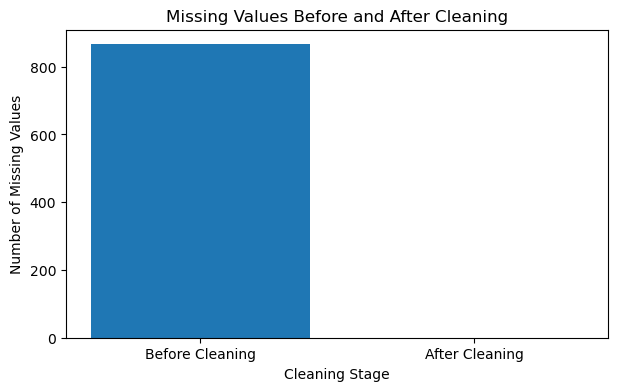

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

plt.bar(
    ["Before Cleaning", "After Cleaning"],
    [
        df.isnull().sum().sum(),
        df_clean.isnull().sum().sum()
    ]
)

plt.title("Missing Values Before and After Cleaning")
plt.ylabel("Number of Missing Values")
plt.xlabel("Cleaning Stage")
plt.show()

### Observation
The chart shows that the total number of missing values decreased from 866 before cleaning to 0 after cleaning.

## Conclusion

The Titanic dataset was cleaned successfully using Python and Pandas. Missing values were handled, 
duplicate records were checked, data types were reviewed, and potential outliers were identified and retained. The cleaned dataset was saved as a new CSV file.

The final dataset contains 891 rows and 11 columns with no missing values or duplicate records.